In [1]:
#read data

import pandas as pd
import bblean
import bblean.plotting as plotting
import bblean.analysis as analysis

df = pd.read_csv('~/Chemical_Space/chembl_scaffoldsParallel.csv')
# Display the first few rows of the DataFrame
df.head()

/home/aylin/miniconda3/envs/RDKit/lib/python3.11/site-packages/bblean/similarity.py:100: UserWarning: C++ optimized similarity calculations not available, falling back to python implementation
  warnings.warn(
/home/aylin/miniconda3/envs/RDKit/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,molregno,canonical_smiles,scaffold,generic_framework
0,1,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl,O=C(c1ccccc1)c1ccc(-n2ncc(=O)[nH]c2=O)cc1,CC1CCC(C2CCC(C(C)C3CCCCC3)CC2)C(C)C1
1,2,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1,O=C(c1ccccc1)c1ccc(-n2ncc(=O)[nH]c2=O)cc1,CC1CCC(C2CCC(C(C)C3CCCCC3)CC2)C(C)C1
2,3,Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1,O=c1cnn(-c2ccc(Cc3ccccc3)cc2)c(=O)[nH]1,CC1CCC(C2CCC(CC3CCCCC3)CC2)C(C)C1
3,4,Cc1ccc(C(=O)c2ccc(-n3ncc(=O)[nH]c3=O)cc2)cc1,O=C(c1ccccc1)c1ccc(-n2ncc(=O)[nH]c2=O)cc1,CC1CCC(C2CCC(C(C)C3CCCCC3)CC2)C(C)C1
4,5,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(Cl)cc1,O=C(c1ccccc1)c1ccc(-n2ncc(=O)[nH]c2=O)cc1,CC1CCC(C2CCC(C(C)C3CCCCC3)CC2)C(C)C1


In [2]:
#keep only unique scaffolds and drop na values
df = df.drop_duplicates(subset=['generic_framework'])
df = df.dropna(subset=['generic_framework'])
df.shape

(353707, 4)

In [3]:
# Load the smiles column as a list
# By default the fps created are of the "ecfp4" kind. Here we use "rdkit"
fps = bblean.fps_from_smiles(df['scaffold'], pack=True, n_features=2048, kind="rdkit")
print(f"Shape: {fps.shape}, DType: {fps.dtype}")

Shape: (353707, 256), DType: uint8


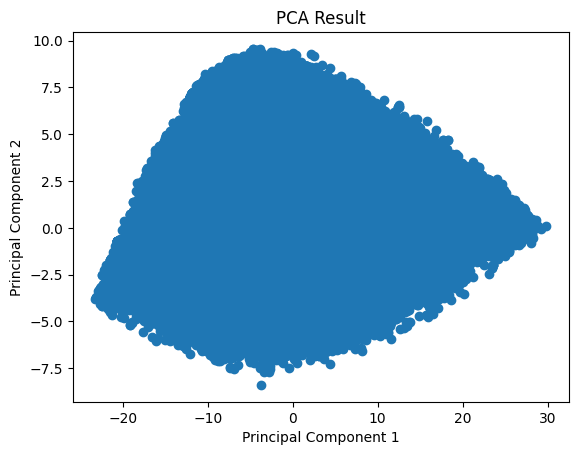

In [4]:
# PCA 
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
fps_scaled = scaler.fit_transform(fps)

# Apply PCA
pca = PCA()
principal_components = pca.fit_transform(fps_scaled)
# Plot the results
plt.scatter(principal_components[:, 0], principal_components[:, 1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Result')
plt.show()


In [5]:
principal_components[:, 20]

array([-2.12939551, -2.12870126,  1.14246701, ..., -0.35866911,
       -0.37583227, -0.38129247], shape=(353707,))

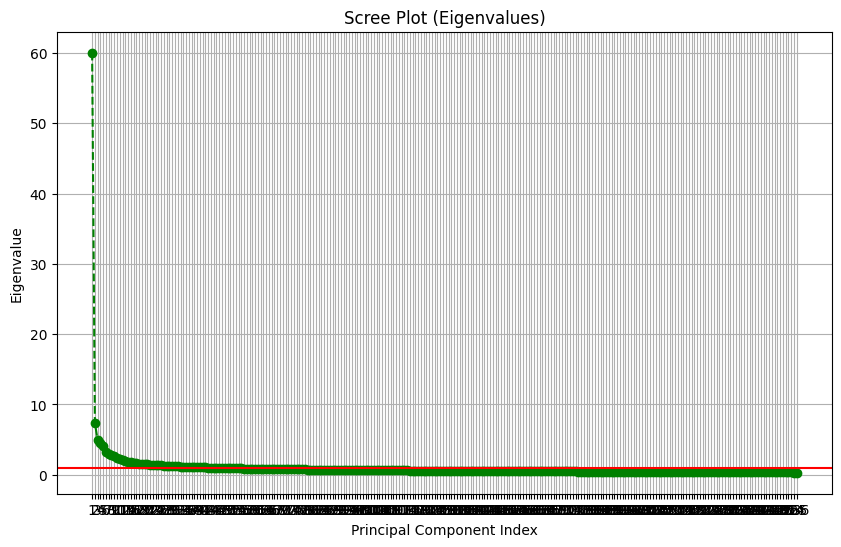

In [6]:
eigenvalues = pca.explained_variance_ #

# Step 4: Create the scree plot
plt.figure(figsize=(10, 6))
# Plot eigenvalues as a line plot
plt.plot(range(1, len(eigenvalues) + 1), eigenvalues, marker='o', linestyle='--', color='green') #
# Optional: Add a horizontal line at y=1 (Kaiser's rule)
plt.axhline(y=1, color='r', linestyle='-') #
plt.title('Scree Plot (Eigenvalues)')
plt.xlabel('Principal Component Index')
plt.ylabel('Eigenvalue')
plt.xticks(range(1, len(eigenvalues) + 1))
plt.grid(True)
plt.show()

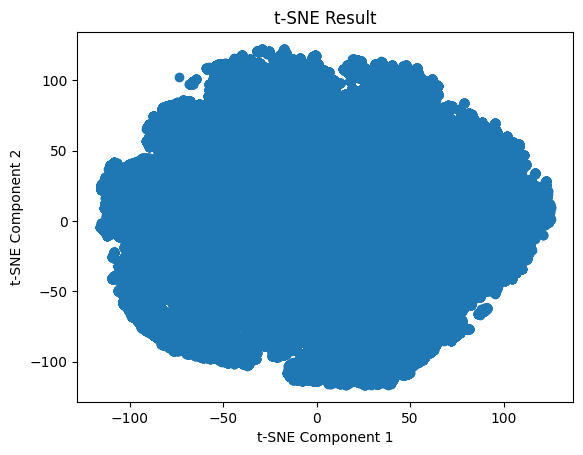

In [7]:

from sklearn.manifold import TSNE
# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30)
tsne_results = tsne.fit_transform(principal_components[:, :10])  # Use the top 50 principal components for t-SNE
# Plot the results
plt.scatter(tsne_results[:, 0], tsne_results[:, 1])
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Result')
plt.show()

In [15]:
df[['tsne1', 'tsne2']] = pd.DataFrame(tsne_results, index=df.index)

df.head()

,molregno,canonical_smiles,scaffold,generic_framework,tsne1,tsne2
0,1,Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl,O=C(c1ccccc1)c1ccc(-n2ncc(=O)[nH]c2=O)cc1,CC1CCC(C2CCC(C(C)C3CCCCC3)CC2)C(C)C1,-75.001633,-4.277291
2,3,Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1,O=c1cnn(-c2ccc(Cc3ccccc3)cc2)c(=O)[nH]1,CC1CCC(C2CCC(CC3CCCCC3)CC2)C(C)C1,-75.056084,-4.451254
9,10,c1cc2cc(c1)-c1cccc(c1)C[n+]1ccc(c3ccccc31)NCCC...,c1cc2cc(c1)-c1cccc(c1)C[n+]1ccc(c3ccccc31)NCCC...,C1CCCCCCC2CCC(CC3CCCC(C3)C3CCCC(C3)CC3CCC(CCCC...,-25.772453,15.084018
12,23,O=C1O/C(=C/Br)CCC1c1cccc2ccccc12,C=C1CCC(c2cccc3ccccc23)C(=O)O1,CC1CC(C)CCC1C1CCCC2CCCCC21,-95.505569,0.627010
18,29,O=C(c1ccccc1)c1cc(-n2ncc(=O)[nH]c2=O)ccc1Cl,O=C(c1ccccc1)c1cccc(-n2ncc(=O)[nH]c2=O)c1,CC1CCC(C2CCCC(C(C)C3CCCCC3)C2)C(C)C1,-39.734161,-24.907429


In [16]:
df.to_csv('~/Chemical_Space/chembl_generic_framework_tsne.csv', index=False)